# 3. Signal-quality assessment and conservative filtering

This block converts the descriptive audit into a conservative signal-quality classification. The original harmonised acquisition-level dataset is not modified or overwritten. Instead, a separate quality-control table is created, containing a small set of interpretable acquisition-level metrics derived directly from the stored frequency-resolved signals.

The aim is to identify clearly problematic acquisitions while preserving borderline cases for possible downstream sensitivity analyses. For that reason, the filtering strategy is intentionally soft. Acquisitions are flagged using protocol- and anatomical-site-specific thresholds based on robust empirical percentiles rather than rigid global cut-offs. The final decision is expressed in three categories: keep, review, and exclude. Only acquisitions showing structural failure or a combination of several adverse indicators are excluded automatically.

This approach preserves traceability, limits unnecessary loss of data, and allows the effect of quality control on sample size and dataset balance to be quantified before the statistical and modelling stages.

In [110]:
# =========================================================
# Block 3
# Conservative signal-quality assessment and filtering
#
# Assumptions:
# - Block 1 and Block 2 have already been executed.
# - The following objects already exist:
#     audit_signals_df
#     EXPECTED_MEASUREMENTS_PER_SITE
#     EXPECTED_ACQUISITIONS_PER_VISIT
# =========================================================

## 3.1. Local functions

In [111]:
def _qc_metrics_from_freq_dict(freq_to_array):
    """
    Compute simple acquisition-level quality metrics from the frequency dictionary.

    Metrics are first computed per frequency channel and then summarised across
    channels using the median, in order to reduce sensitivity to a single
    anomalous frequency.
    """
    eps = 1e-8

    if not isinstance(freq_to_array, dict) or len(freq_to_array) == 0:
        return {
            "qc_n_channels_used": 0,
            "p2p_median": np.nan,
            "rms_median": np.nan,
            "std_median": np.nan,
            "drift_ratio_median": np.nan,
            "roughness_ratio_median": np.nan,
        }

    p2p_list = []
    rms_list = []
    std_list = []
    drift_ratio_list = []
    roughness_ratio_list = []

    for _, arr in freq_to_array.items():
        x = np.asarray(arr, dtype=float)

        if x.size < 10:
            continue

        p2p = float(np.max(x) - np.min(x))
        rms = float(np.sqrt(np.mean(x ** 2)))
        std = float(np.std(x))

        edge_n = max(5, int(round(0.10 * x.size)))
        start_mean = float(np.mean(x[:edge_n]))
        end_mean = float(np.mean(x[-edge_n:]))

        drift_ratio = abs(end_mean - start_mean) / (p2p + eps)
        roughness_ratio = float(np.std(np.diff(x))) / (std + eps)

        p2p_list.append(p2p)
        rms_list.append(rms)
        std_list.append(std)
        drift_ratio_list.append(drift_ratio)
        roughness_ratio_list.append(roughness_ratio)

    if len(p2p_list) == 0:
        return {
            "qc_n_channels_used": 0,
            "p2p_median": np.nan,
            "rms_median": np.nan,
            "std_median": np.nan,
            "drift_ratio_median": np.nan,
            "roughness_ratio_median": np.nan,
        }

    return {
        "qc_n_channels_used": int(len(p2p_list)),
        "p2p_median": float(np.median(p2p_list)),
        "rms_median": float(np.median(rms_list)),
        "std_median": float(np.median(std_list)),
        "drift_ratio_median": float(np.median(drift_ratio_list)),
        "roughness_ratio_median": float(np.median(roughness_ratio_list)),
    }

In [112]:
def _build_signal_qc_table(signals_df):
    """
    Create a quality-audit table with one row per acquisition.
    """
    qc_metrics_df = pd.DataFrame(
        [_qc_metrics_from_freq_dict(freq_dict) for freq_dict in signals_df["freq_to_array"]]
    )

    out = pd.concat(
        [
            signals_df.reset_index(drop=True).copy(),
            qc_metrics_df.reset_index(drop=True),
        ],
        axis=1,
    )

    return out

In [113]:
def _add_groupwise_qc_flags(qc_df):
    """
    Add conservative quality flags using protocol- and site-specific empirical thresholds.

    Threshold logic:
    - low amplitude / low information: lower 5th percentile
    - high drift / high roughness: upper 95th percentile

    Grouping:
    - protocol_version + site_code

    Final decision:
    - exclude: structural failure or several concurrent adverse indicators
    - review: one or two adverse indicators
    - keep: no adverse indicators
    """
    out = qc_df.copy()
    group_cols = ["protocol_version", "site_code"]

    # Groupwise thresholds
    out["thr_p2p_low"] = out.groupby(group_cols)["p2p_median"].transform(
        lambda s: s.quantile(0.05)
    )
    out["thr_rms_low"] = out.groupby(group_cols)["rms_median"].transform(
        lambda s: s.quantile(0.05)
    )
    out["thr_drift_high"] = out.groupby(group_cols)["drift_ratio_median"].transform(
        lambda s: s.quantile(0.95)
    )
    out["thr_roughness_high"] = out.groupby(group_cols)["roughness_ratio_median"].transform(
        lambda s: s.quantile(0.95)
    )

    # Basic structural checks
    out["flag_no_channels"] = out["qc_n_channels_used"].fillna(0).astype(int) == 0
    out["flag_parse_fail"] = ~out["parse_ok"].fillna(False)

    # Soft quality flags
    out["flag_low_p2p"] = out["p2p_median"] < out["thr_p2p_low"]
    out["flag_low_rms"] = out["rms_median"] < out["thr_rms_low"]
    out["flag_high_drift"] = out["drift_ratio_median"] > out["thr_drift_high"]
    out["flag_high_roughness"] = out["roughness_ratio_median"] > out["thr_roughness_high"]

    flag_cols = [
        "flag_low_p2p",
        "flag_low_rms",
        "flag_high_drift",
        "flag_high_roughness",
    ]

    out["qc_flag_count"] = out[flag_cols].fillna(False).astype(int).sum(axis=1)

    # Conservative decision rule
    severe_combo = (
        out["flag_low_p2p"].fillna(False) &
        out["flag_low_rms"].fillna(False) &
        (
            out["flag_high_drift"].fillna(False) |
            out["flag_high_roughness"].fillna(False)
        )
    )

    structural_fail = out["flag_no_channels"] | out["flag_parse_fail"]

    out["qc_decision"] = "keep"
    out.loc[out["qc_flag_count"] >= 1, "qc_decision"] = "review"
    out.loc[structural_fail | severe_combo | (out["qc_flag_count"] >= 3), "qc_decision"] = "exclude"

    # Human-readable reason
    reason_cols = [
        "flag_no_channels",
        "flag_parse_fail",
        "flag_low_p2p",
        "flag_low_rms",
        "flag_high_drift",
        "flag_high_roughness",
    ]
    def _build_reason(row):
      reasons = []
      for c in reason_cols:
          if bool(row[c]):
              reasons.append(c.replace("flag_", ""))
      return ", ".join(reasons) if reasons else "none"

    out["qc_reason"] = out[reason_cols].apply(_build_reason, axis=1)

    return out


In [114]:
def _build_qc_summary_tables(qc_df):
    """
    Build compact summary tables to quantify the impact of QC.
    This version avoids pandas categorical-groupby alignment issues by using
    a string copy of timepoint for grouped summaries.
    """
    out = qc_df.copy()

    # Avoid categorical-groupby size mismatch
    out["timepoint_str"] = out["timepoint"].astype(str)

    decision_summary_df = (
        out.groupby(["protocol_version", "qc_decision"], as_index=False)
        .agg(
            n_acquisitions=("signal_record_id", "nunique"),
            n_patients=("global_patient_id", "nunique"),
        )
        .sort_values(["protocol_version", "qc_decision"])
        .reset_index(drop=True)
    )

    impact_summary_df = (
        out.groupby(["protocol_version", "timepoint_str"], as_index=False)
        .agg(
            n_raw=("signal_record_id", "nunique"),
            n_keep=("qc_decision", lambda s: int((s == "keep").sum())),
            n_review=("qc_decision", lambda s: int((s == "review").sum())),
            n_exclude=("qc_decision", lambda s: int((s == "exclude").sum())),
        )
        .rename(columns={"timepoint_str": "timepoint"})
        .sort_values(
            ["protocol_version", "timepoint"],
            key=lambda col: col.map(TIMEPOINT_ORDER) if col.name == "timepoint" else col,
        )
        .reset_index(drop=True)
    )

    impact_summary_df["pct_excluded"] = (
        100 * impact_summary_df["n_exclude"] / impact_summary_df["n_raw"].replace(0, np.nan)
    )

    flag_summary_df = pd.DataFrame({
        "flag_name": [
            "flag_low_p2p",
            "flag_low_rms",
            "flag_high_drift",
            "flag_high_roughness",
            "flag_no_channels",
            "flag_parse_fail",
        ],
        "n_acquisitions": [
            int(out["flag_low_p2p"].fillna(False).sum()),
            int(out["flag_low_rms"].fillna(False).sum()),
            int(out["flag_high_drift"].fillna(False).sum()),
            int(out["flag_high_roughness"].fillna(False).sum()),
            int(out["flag_no_channels"].fillna(False).sum()),
            int(out["flag_parse_fail"].fillna(False).sum()),
        ],
    }).sort_values("n_acquisitions", ascending=False).reset_index(drop=True)

    return decision_summary_df, impact_summary_df, flag_summary_df

## 3.2. Build QC tables

In [115]:
signals_qc_df = _build_signal_qc_table(audit_signals_df)
signals_qc_df = _add_groupwise_qc_flags(signals_qc_df)

qc_decision_summary_df, qc_impact_summary_df, qc_flag_summary_df = _build_qc_summary_tables(signals_qc_df)


In [116]:
# Conservative analytical dataset:
# keep both "keep" and "review", exclude only clear failures / strong outliers
signals_analysis_df = signals_qc_df.loc[
    signals_qc_df["qc_decision"] != "exclude"
].copy()

In [117]:
# Conservative analytical dataset:
# keep both "keep" and "review", exclude only clear failures / strong outliers
signals_analysis_df = signals_qc_df.loc[
    signals_qc_df["qc_decision"] != "exclude"
].copy()

In [118]:
# Candidate acquisitions for later manual review
signals_review_df = signals_qc_df.loc[
    signals_qc_df["qc_decision"] == "review"
].copy()

signals_excluded_df = signals_qc_df.loc[
    signals_qc_df["qc_decision"] == "exclude"
].copy()

## 3.3. Build filtered datasets from QC decisions

In [119]:
signals_analysis_df = signals_qc_df.loc[
    signals_qc_df["qc_decision"] != "exclude"
].copy()

signals_keep_only_df = signals_qc_df.loc[
    signals_qc_df["qc_decision"] == "keep"
].copy()

signals_review_df = signals_qc_df.loc[
    signals_qc_df["qc_decision"] == "review"
].copy()

signals_excluded_df = signals_qc_df.loc[
    signals_qc_df["qc_decision"] == "exclude"
].copy()

## 3.4. Display tables

In [120]:
print("\nQC decision summary")
display(qc_decision_summary_df)


QC decision summary


,protocol_version,qc_decision,n_acquisitions,n_patients
0,new,exclude,59,18
1,new,keep,1433,86
2,new,review,89,45
3,old,exclude,77,24
4,old,keep,1718,156
5,old,review,119,43


In [121]:
print("\nQC impact summary by protocol and timepoint")
display(qc_impact_summary_df)


QC impact summary by protocol and timepoint


,protocol_version,timepoint,n_raw,n_keep,n_review,n_exclude,pct_excluded
0,new,FUP,1581,1433,89,59,3.731815
1,old,PRE,440,418,22,0,0.000000
2,old,POST,1140,978,92,70,6.140351
3,old,FUP,333,321,5,7,2.102102
4,old,UNKNOWN,1,1,0,0,0.000000


In [122]:
print("\nQC flag summary")
display(qc_flag_summary_df)


QC flag summary


,flag_name,n_acquisitions
0,flag_low_p2p,177
1,flag_low_rms,177
2,flag_high_drift,177
3,flag_high_roughness,177
4,flag_no_channels,0
5,flag_parse_fail,0


In [123]:
print("\nAcquisition-level QC table")
display(
    signals_qc_df[
        [
            "signal_record_id",
            "protocol_version",
            "global_patient_id",
            "hospital_patient_id",
            "timepoint",
            "site_code",
            "measurement_index_site",
            "qc_n_channels_used",
            "p2p_median",
            "rms_median",
            "drift_ratio_median",
            "roughness_ratio_median",
            "qc_flag_count",
            "qc_decision",
            "qc_reason",
        ]
    ].head(20)
)



Acquisition-level QC table


,signal_record_id,protocol_version,global_patient_id,hospital_patient_id,timepoint,site_code,measurement_index_site,qc_n_channels_used,p2p_median,rms_median,drift_ratio_median,roughness_ratio_median,qc_flag_count,qc_decision,qc_reason
0,sig_000006,new,159,579,FUP,B,1,9,3.253757,0.409288,0.015423,0.031952,0,keep,none
1,sig_000007,new,159,579,FUP,B,2,9,3.413835,0.436061,0.003637,0.032208,0,keep,none
2,sig_000008,new,159,579,FUP,B,3,9,3.207032,0.353959,0.002109,0.032964,0,keep,none
3,sig_000009,new,159,579,FUP,B,4,9,2.917012,0.408117,0.004510,0.033237,0,keep,none
4,sig_000010,new,159,579,FUP,B,5,9,2.888546,0.274068,0.023516,0.027477,0,keep,none
5,sig_000011,new,159,579,FUP,B,6,9,2.729402,0.327400,0.009092,0.029078,0,keep,none
6,sig_000012,new,159,579,FUP,P,1,9,1.073773,0.293037,0.007793,0.043507,0,keep,none
7,sig_000013,new,159,579,FUP,P,2,9,1.117992,0.136358,0.010941,0.038369,0,keep,none
8,sig_000014,new,159,579,FUP,P,3,9,0.516262,0.105731,0.037941,0.058742,0,keep,none
9,sig_000015,new,159,579,FUP,P,4,9,0.388629,0.095815,0.024650,0.056353,0,keep,none


In [124]:
print("\nReview candidates")
display(
    signals_review_df[
        [
            "signal_record_id",
            "protocol_version",
            "global_patient_id",
            "timepoint",
            "site_code",
            "measurement_index_site",
            "p2p_median",
            "rms_median",
            "drift_ratio_median",
            "roughness_ratio_median",
            "qc_flag_count",
            "qc_reason",
        ]
    ].head(30)
)


Review candidates


,signal_record_id,protocol_version,global_patient_id,timepoint,site_code,measurement_index_site,p2p_median,rms_median,drift_ratio_median,roughness_ratio_median,qc_flag_count,qc_reason
36,sig_000042,new,161,FUP,B,1,1.271898,0.342282,0.284167,0.027984,1,high_drift
38,sig_000046,new,161,FUP,B,3,1.204779,0.302243,0.231642,0.026833,1,high_drift
39,sig_000048,new,161,FUP,B,4,2.069412,0.342275,0.198558,0.024671,1,high_drift
130,sig_000118,new,165,FUP,A,5,3.202027,0.441956,0.049129,0.049539,1,high_drift
201,sig_000189,new,169,FUP,A,4,3.690024,0.469806,0.007468,0.065876,1,high_roughness
326,sig_000314,new,176,FUP,A,3,4.198051,0.724467,0.051910,0.052786,1,high_drift
396,sig_000384,new,180,FUP,A,1,1.466176,0.188185,0.043764,0.064098,1,high_roughness
416,sig_000404,new,181,FUP,A,2,4.204440,0.862418,0.050984,0.049372,1,high_drift
419,sig_000407,new,181,FUP,A,5,4.191643,0.784920,0.049504,0.042672,1,high_drift
437,sig_000425,new,182,FUP,A,5,3.824250,0.659232,0.013400,0.063666,1,high_roughness


In [125]:
print("\nExcluded acquisitions")
display(
    signals_excluded_df[
        [
            "signal_record_id",
            "protocol_version",
            "global_patient_id",
            "timepoint",
            "site_code",
            "measurement_index_site",
            "p2p_median",
            "rms_median",
            "drift_ratio_median",
            "roughness_ratio_median",
            "qc_flag_count",
            "qc_reason",
        ]
    ].head(30)
)


Excluded acquisitions


,signal_record_id,protocol_version,global_patient_id,timepoint,site_code,measurement_index_site,p2p_median,rms_median,drift_ratio_median,roughness_ratio_median,qc_flag_count,qc_reason
715,sig_000725,new,198,FUP,B,5,0.070936,0.015266,0.277005,0.106674,4,"low_p2p, low_rms, high_drift, high_roughness"
716,sig_000727,new,198,FUP,B,6,0.096720,0.021794,0.125910,0.092252,3,"low_p2p, low_rms, high_roughness"
719,sig_000722,new,198,FUP,B,3,0.093194,0.019713,0.281816,0.115660,4,"low_p2p, low_rms, high_drift, high_roughness"
720,sig_000724,new,198,FUP,B,4,0.089626,0.017881,0.196640,0.109577,4,"low_p2p, low_rms, high_drift, high_roughness"
722,sig_000728,new,198,FUP,B,6,0.125546,0.024216,0.147374,0.080071,3,"low_p2p, low_rms, high_drift"
724,sig_000730,new,198,FUP,P,2,0.063996,0.016071,0.183741,0.091228,4,"low_p2p, low_rms, high_drift, high_roughness"
725,sig_000731,new,198,FUP,P,3,0.093407,0.018613,0.300959,0.091475,4,"low_p2p, low_rms, high_drift, high_roughness"
726,sig_000732,new,198,FUP,P,4,0.101234,0.022138,0.214975,0.080718,4,"low_p2p, low_rms, high_drift, high_roughness"
727,sig_000733,new,198,FUP,P,5,0.099636,0.016072,0.298634,0.113005,4,"low_p2p, low_rms, high_drift, high_roughness"
728,sig_000734,new,198,FUP,P,6,0.085352,0.018292,0.383467,0.099618,4,"low_p2p, low_rms, high_drift, high_roughness"


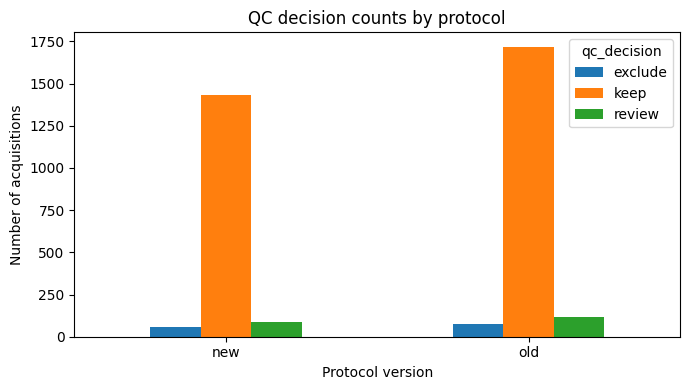

In [126]:
## Simple graphical check of QC impact

qc_plot_df = (
    qc_decision_summary_df.pivot(
        index="protocol_version",
        columns="qc_decision",
        values="n_acquisitions",
    )
    .fillna(0)
)

ax = qc_plot_df.plot(kind="bar", figsize=(7, 4))
ax.set_title("QC decision counts by protocol")
ax.set_xlabel("Protocol version")
ax.set_ylabel("Number of acquisitions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Visual QC comparison: raw vs filtered analysis dataset
Site=A, timepoint=FUP, frequency=800 Hz

===== Protocol: old =====
Before QC


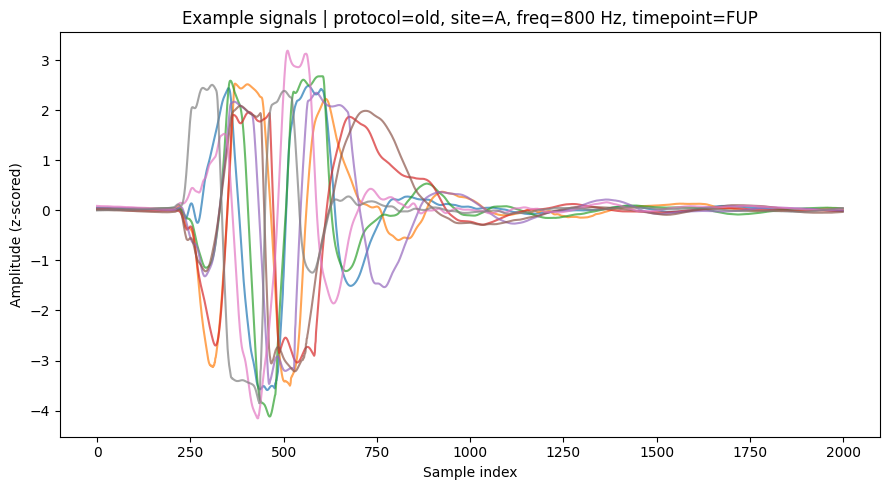

After QC (analysis dataset: keep + review)


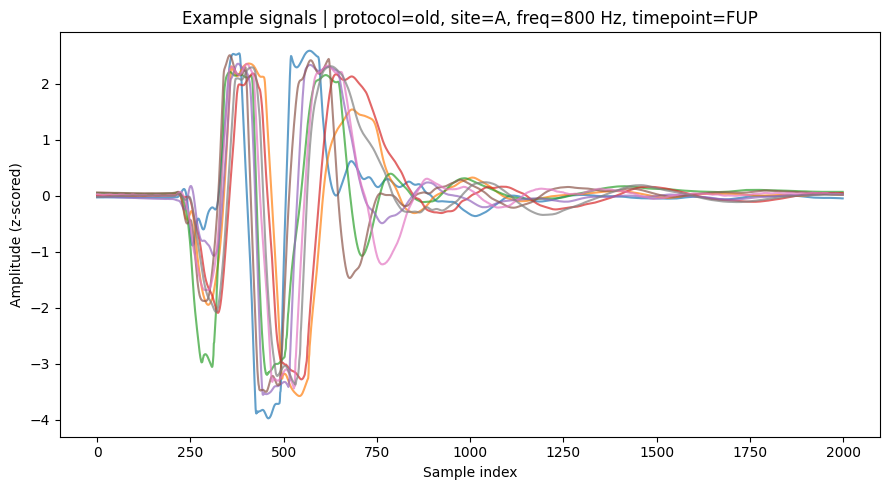


===== Protocol: new =====
Before QC


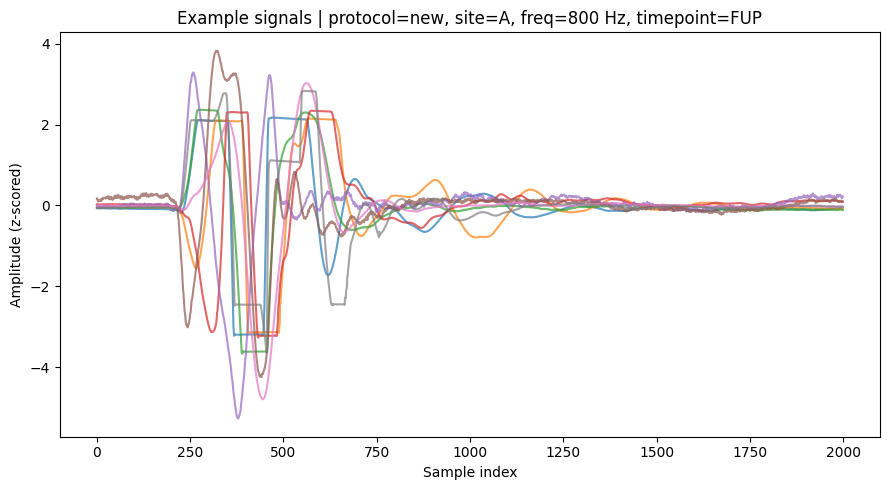

After QC (analysis dataset: keep + review)


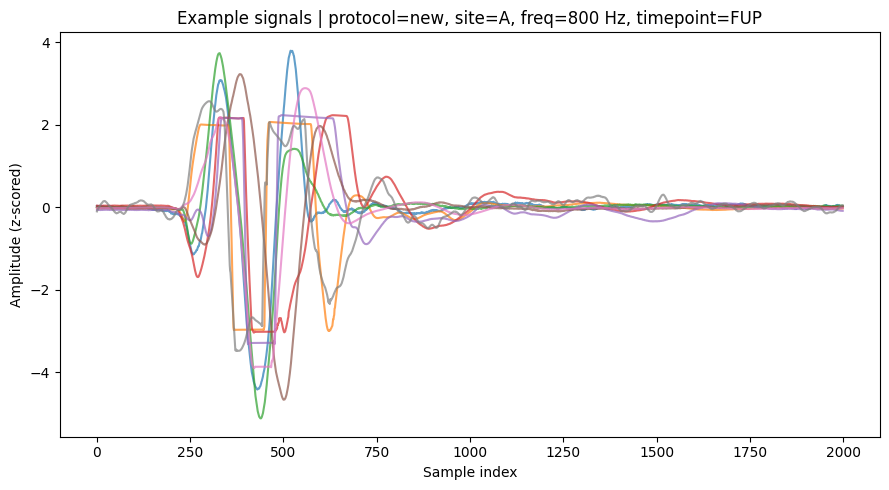

In [127]:
## Visual QC comparison: before vs after conservative filtering
# The comparison uses the analysis dataset (keep + review), which is more stable
# than keep-only and better reflects the conservative filtering strategy.

QC_EXAMPLE_FREQUENCY = 800
QC_EXAMPLE_TIMEPOINT = "FUP"
QC_EXAMPLE_SITE = "A"
QC_EXAMPLE_PROTOCOLS = ["old", "new"]
QC_N_EXAMPLES = 8

print("\nVisual QC comparison: raw vs filtered analysis dataset")
print(
    f"Site={QC_EXAMPLE_SITE}, "
    f"timepoint={QC_EXAMPLE_TIMEPOINT}, "
    f"frequency={QC_EXAMPLE_FREQUENCY} Hz"
)

for protocol_version in QC_EXAMPLE_PROTOCOLS:
    print(f"\n===== Protocol: {protocol_version} =====")

    print("Before QC")
    _audit_plot_signal_examples(
        signals_df=audit_signals_df,
        protocol_version=protocol_version,
        site_code=QC_EXAMPLE_SITE,
        frequency_hz=QC_EXAMPLE_FREQUENCY,
        timepoint=QC_EXAMPLE_TIMEPOINT,
        n_examples=QC_N_EXAMPLES,
        normalise=True,
    )

    print("After QC (analysis dataset: keep + review)")
    _audit_plot_signal_examples(
        signals_df=signals_analysis_df,
        protocol_version=protocol_version,
        site_code=QC_EXAMPLE_SITE,
        frequency_hz=QC_EXAMPLE_FREQUENCY,
        timepoint=QC_EXAMPLE_TIMEPOINT,
        n_examples=QC_N_EXAMPLES,
        normalise=True,
    )


Site: A

Protocol: old | Before QC


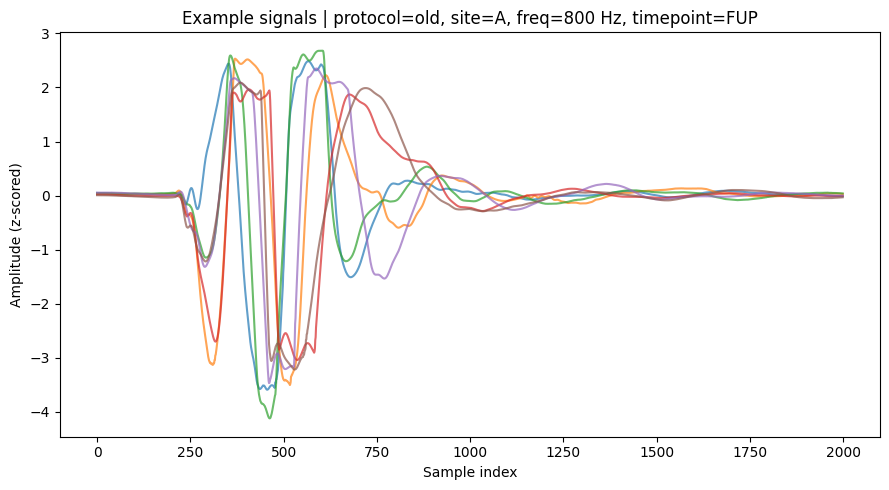

Protocol: old | After QC (analysis dataset)


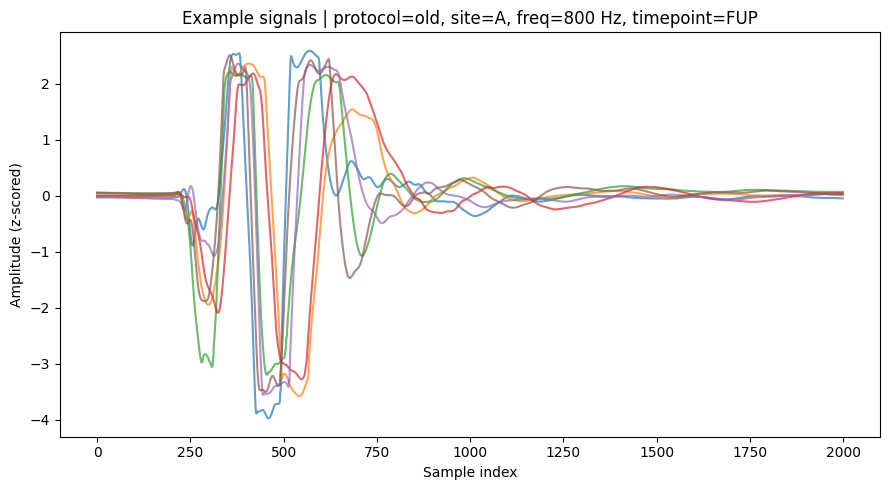


Protocol: new | Before QC


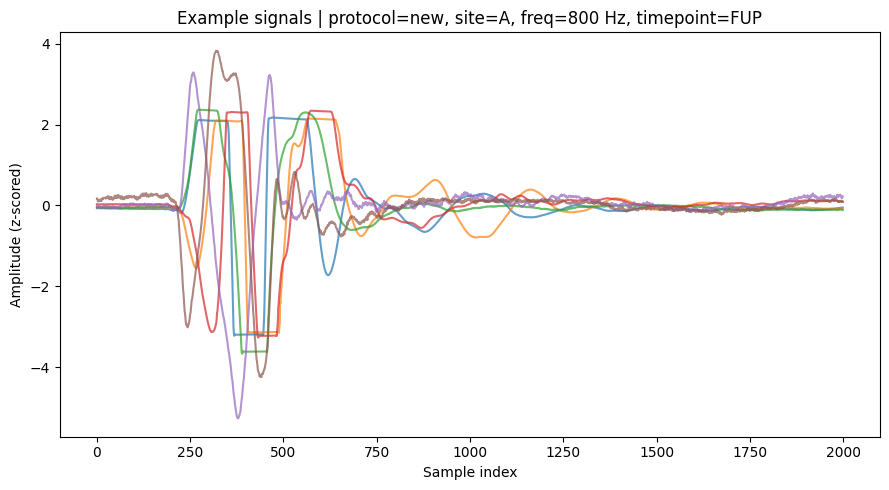

Protocol: new | After QC (analysis dataset)


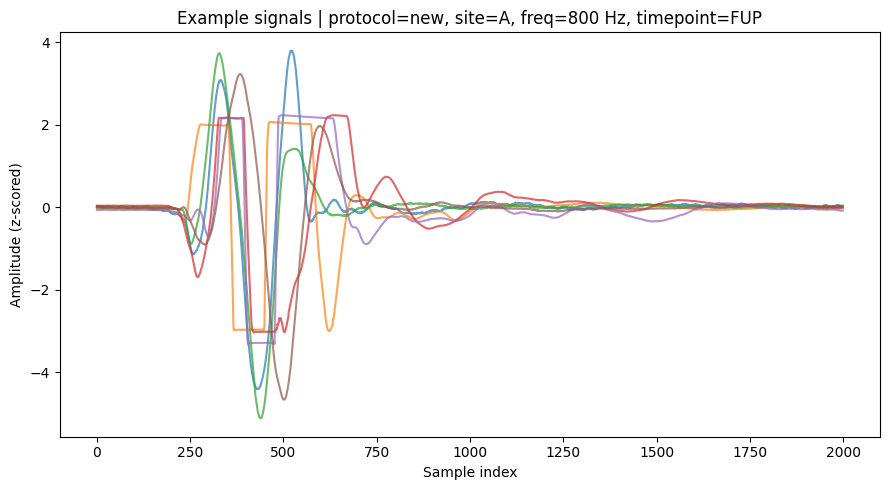


Site: B

Protocol: old | Before QC


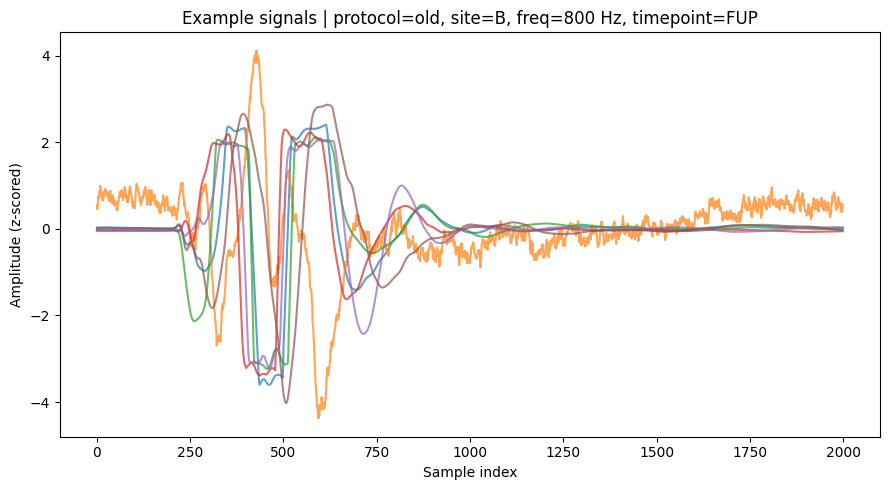

Protocol: old | After QC (analysis dataset)


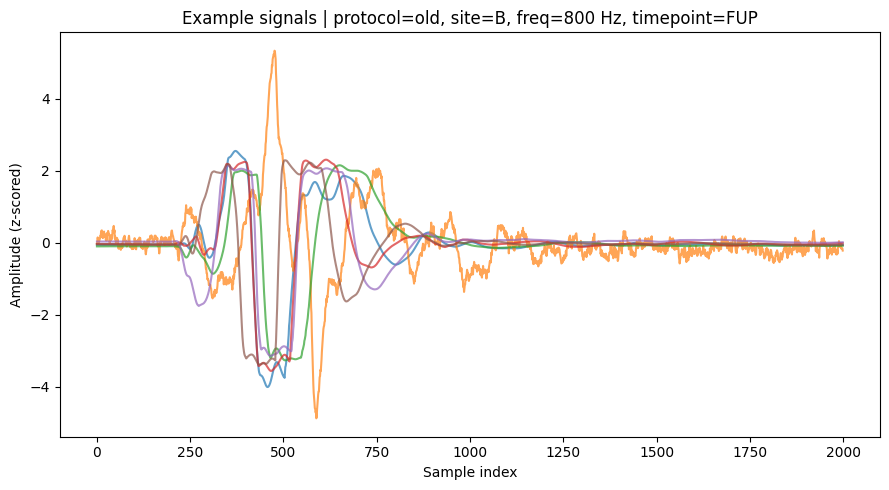


Protocol: new | Before QC


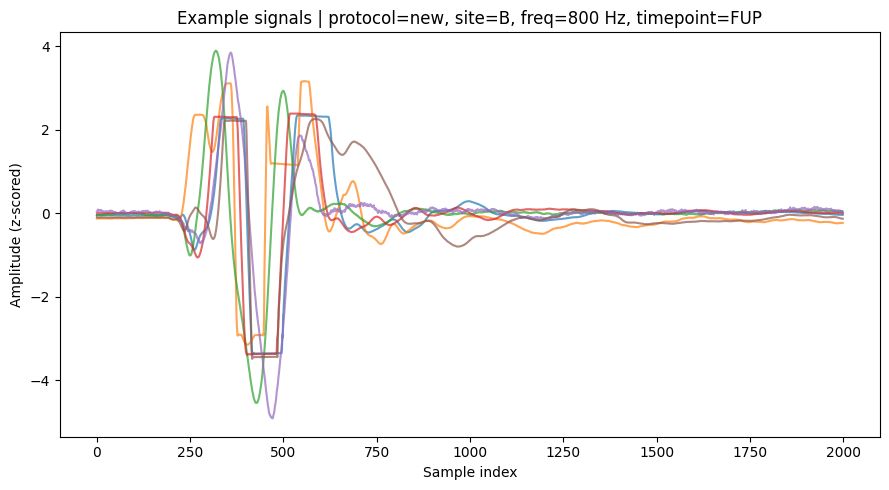

Protocol: new | After QC (analysis dataset)


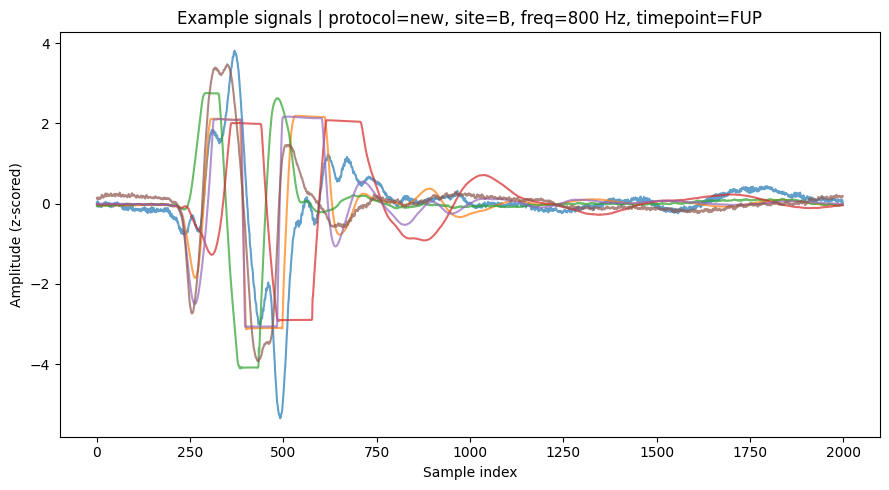


Site: P

Protocol: old | Before QC


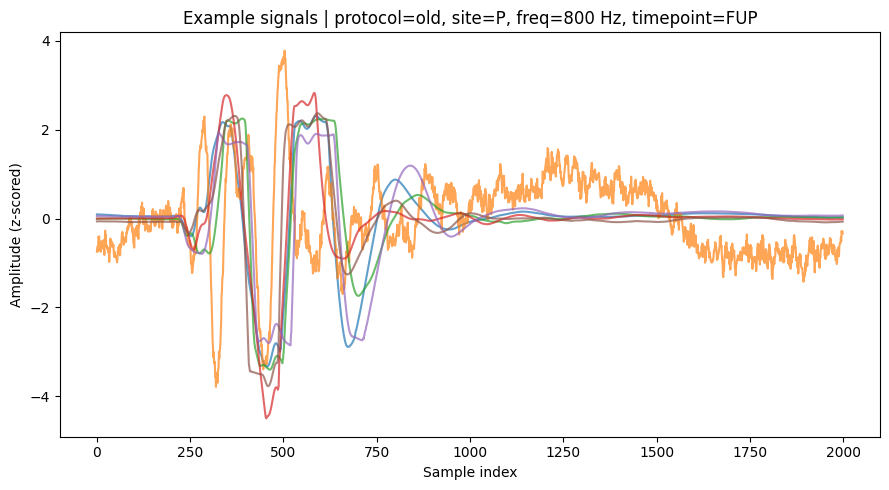

Protocol: old | After QC (analysis dataset)


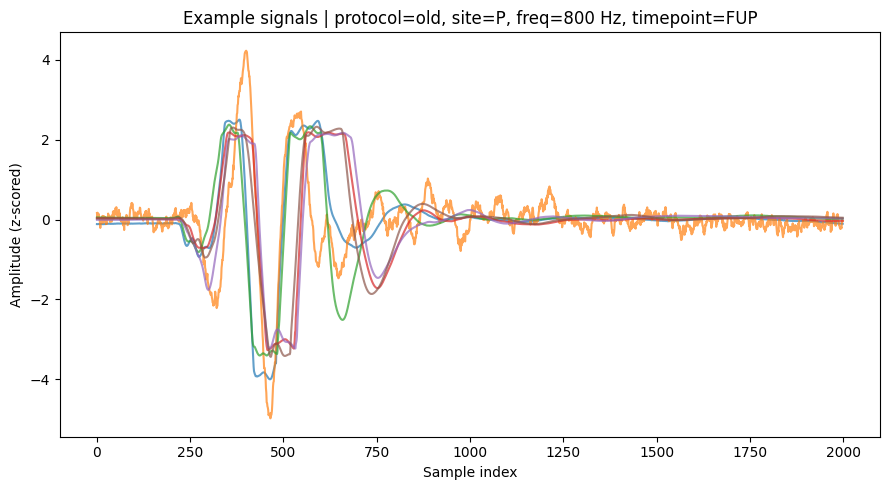


Protocol: new | Before QC


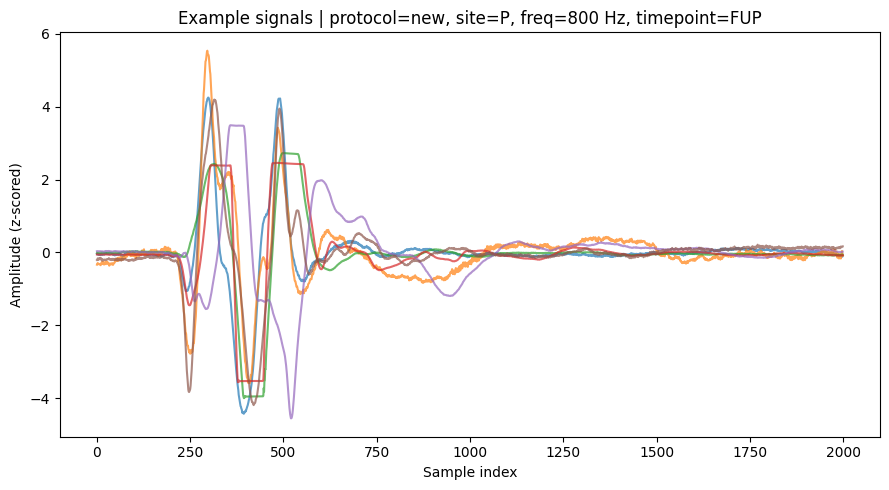

Protocol: new | After QC (analysis dataset)


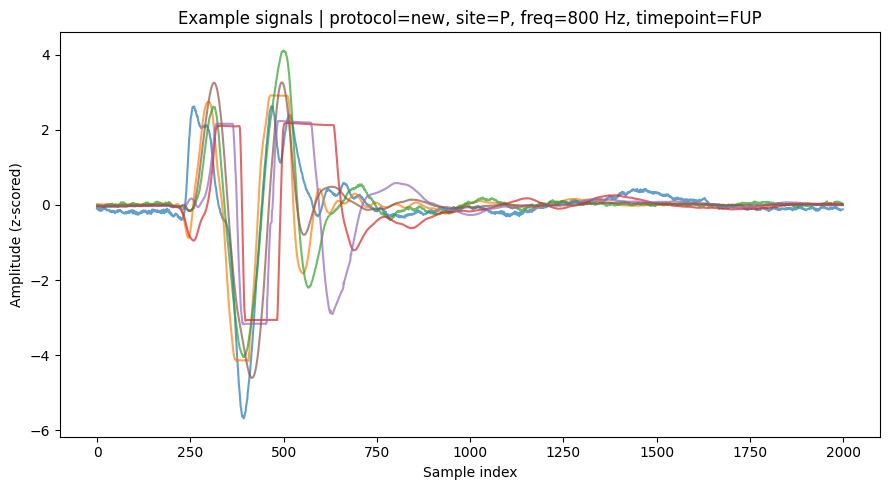

In [128]:
## Optional visual QC comparison by anatomical site
# This second view is optional. It is useful if you want one figure per site.

QC_EXAMPLE_FREQUENCY = 800
QC_EXAMPLE_TIMEPOINT = "FUP"
QC_EXAMPLE_PROTOCOLS = ["old", "new"]
QC_EXAMPLE_SITES = ["A", "B", "P"]
QC_N_EXAMPLES = 6

for site_code in QC_EXAMPLE_SITES:
    print("\n==============================")
    print(f"Site: {site_code}")
    print("==============================")

    for protocol_version in QC_EXAMPLE_PROTOCOLS:
        print(f"\nProtocol: {protocol_version} | Before QC")
        _audit_plot_signal_examples(
            signals_df=audit_signals_df,
            protocol_version=protocol_version,
            site_code=site_code,
            frequency_hz=QC_EXAMPLE_FREQUENCY,
            timepoint=QC_EXAMPLE_TIMEPOINT,
            n_examples=QC_N_EXAMPLES,
            normalise=True,
        )

        print(f"Protocol: {protocol_version} | After QC (analysis dataset)")
        _audit_plot_signal_examples(
            signals_df=signals_analysis_df,
            protocol_version=protocol_version,
            site_code=site_code,
            frequency_hz=QC_EXAMPLE_FREQUENCY,
            timepoint=QC_EXAMPLE_TIMEPOINT,
            n_examples=QC_N_EXAMPLES,
            normalise=True,
        )